<a href="https://colab.research.google.com/github/Stonetenth2005/Deep-Learning/blob/main/3-Perceptron%20Loss%20Funtion/Perceptron_loss_funtion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False, class_sep=15)

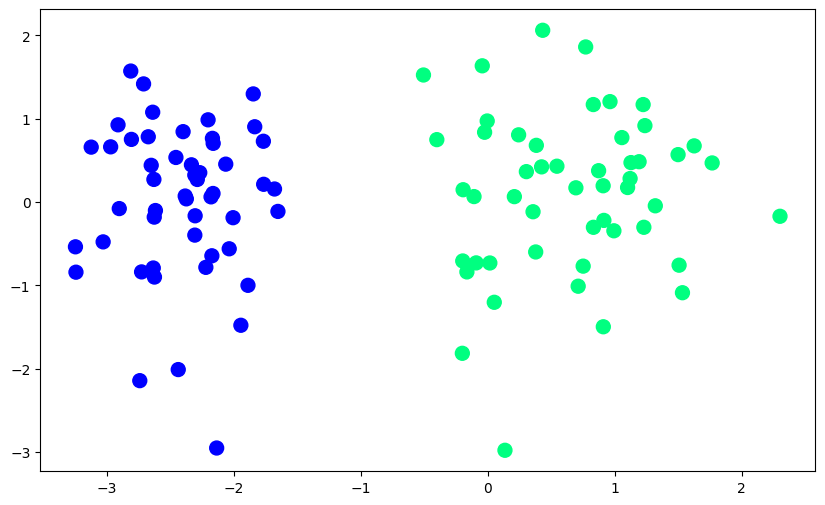

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y, cmap='winter',s=100)

In [6]:
def perceptron(X,y):
  w1=w2=b=1
  lr = 0.1

  for j in range(1000):

    for i in range(X.shape[0]):

      z = w1*X[i][0] + w2*X[i][1] + b

      if z*y[i] < 0:
        w1 = w1 + lr*(y[i]*X[i][0])
        w2 = w2 + lr*(y[i]*X[i][1])
        b = b + lr*y[i]

  return w1,w2,b

In [7]:
w1,w2,b = perceptron(X,y)

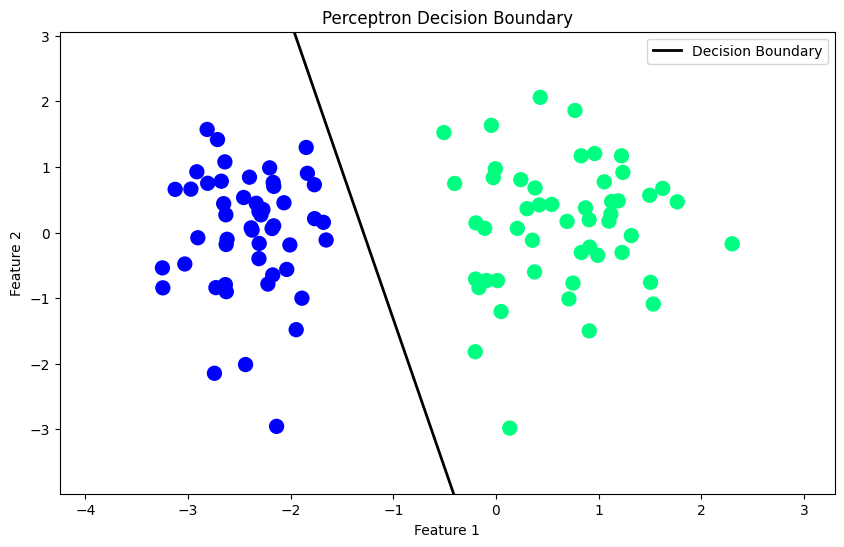

In [9]:
# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y, cmap='winter',s=100)

# Calculate the decision boundary line
# The equation of the decision boundary is w1*x + w2*y + b = 0
if w2 != 0: # Avoid division by zero, standard case
  # y = (-w1*x - b) / w2
  # We need to create an array for the x-values over which to plot the line
  x_line = np.array([x_min, x_max])
  y_line = (-w1 * x_line - b) / w2
  plt.plot(x_line, y_line, 'k-', linewidth=2, label='Decision Boundary')
elif w1 != 0: # w2 is 0, so it's a vertical line: x = -b/w1
  x_line = -b / w1
  plt.axvline(x=x_line, color='k', linestyle='-', linewidth=2, label='Decision Boundary')
else: # Both w1 and w2 are zero, no clear decision boundary
  print("Both w1 and w2 are zero. No clear decision boundary to plot.")

plt.title('Perceptron Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.ylim(y_min, y_max) # Ensure the plot limits include the decision boundary
plt.xlim(x_min, x_max)
plt.legend()
plt.show()